In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score
from sksurv.metrics import brier_score
from sksurv.metrics import concordance_index_censored
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines import KaplanMeierFitter
from sksurv.util import Surv
warnings.filterwarnings('ignore')

1. IPCW weights for LightGBM
2. Add manual configs for LightGBM for each horizon
3. Fixed blend weights gbsa and lgbm (before 72h)


### Data preprocessing

In [52]:
# Load data
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')
meta = pd.read_csv('Data/metaData.csv')

# Converting to dataframe
train = pd.DataFrame(train)
test = pd.DataFrame(test)

# Splitting train and test into X_train and y_train
X_train = train.drop(columns=['event', 'event_id', 'time_to_hit_hours'])
y_train = train[['time_to_hit_hours', 'event']]
y_train['event'] = y_train['event'].astype(int)

# y_train for gbsa
y_train_surv = Surv.from_arrays(event = y_train["event"].astype(bool), 
                                time = y_train["time_to_hit_hours"])
event_val = y_train['event'].copy() # Later use for oof prediction loop

# y_train for lightgbm (splitting each horizons)
y_train_lgbm_p12 = ((train['event'] == 1) & (train['time_to_hit_hours'] <= 12)).astype(int)
y_train_lgbm_p24 = ((train['event'] == 1) & (train['time_to_hit_hours'] <= 24)).astype(int)
y_train_lgbm_p48 = ((train['event'] == 1) & (train['time_to_hit_hours'] <= 48)).astype(int)
y_train_lgbm_p72 = ((train['event'] == 1) & (train['time_to_hit_hours'] <= 72)).astype(int)

# Dropping event_id for X_test
X_test = test.drop(columns=['event_id'])
event_id = test['event_id'] # Save event_id for submitting

### Distribution analysis

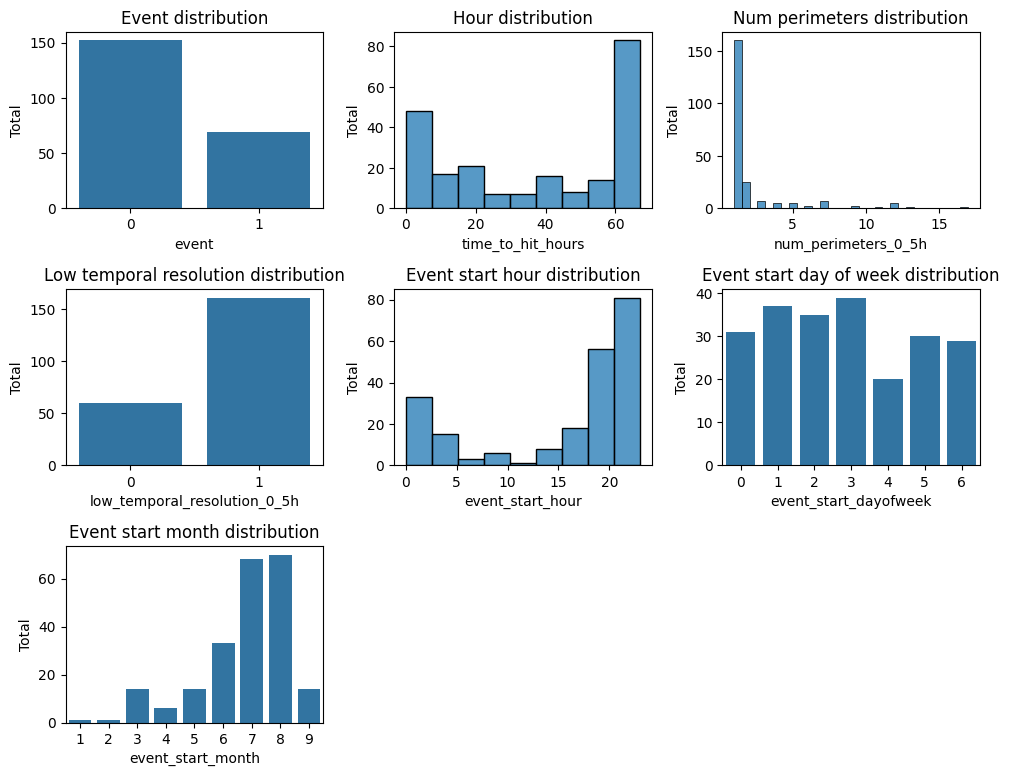

In [53]:
#Cardinality check (categorical)
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
axes = axes.flatten()

sns.countplot(data=train, x='event', ax=axes[0])
axes[0].set_ylabel("Total")
axes[0].set_title('Event distribution')

sns.histplot(data=train, x='time_to_hit_hours', ax=axes[1])
axes[1].set_ylabel("Total")
axes[1].set_title('Hour distribution')

sns.histplot(data=train, x='num_perimeters_0_5h', ax=axes[2])
axes[2].set_ylabel("Total")
axes[2].set_title('Num perimeters distribution')

sns.countplot(data=train, x='low_temporal_resolution_0_5h', ax=axes[3])
axes[3].set_ylabel("Total")
axes[3].set_title('Low temporal resolution distribution')

sns.histplot(data=train, x='event_start_hour', ax=axes[4])
axes[4].set_ylabel("Total")
axes[4].set_title('Event start hour distribution')

sns.countplot(data=train, x='event_start_dayofweek', ax=axes[5])
axes[5].set_ylabel("Total")
axes[5].set_title('Event start day of week distribution')

sns.countplot(data=train, x='event_start_month', ax=axes[6])
axes[6].set_ylabel("Total")
axes[6].set_title('Event start month distribution')

for i in range(7, 12):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Feature engineering

##### One-hot encodingPerform one-hot encoding for low_temporal_resolution_0_5h


In [54]:
one_hot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    dtype=np.int8
)
one_hot_encoder.set_output(transform='pandas')

# One hot for X_train
one_hot_col = one_hot_encoder.fit_transform(X_train[['low_temporal_resolution_0_5h']])
X_train = pd.concat([X_train, pd.DataFrame(one_hot_col, index=X_train.index)], axis=1).drop(columns = 'low_temporal_resolution_0_5h')

# One hot for X_test
one_hot_col = one_hot_encoder.transform(X_test[['low_temporal_resolution_0_5h']])
X_test = pd.concat([X_test, pd.DataFrame(one_hot_col, index=X_test.index)], axis=1).drop(columns = 'low_temporal_resolution_0_5h') # type: ignore

##### Target encoding for categorical data

In [55]:
# Target encoding will be included when doing OOF prediction to avoid data leakage
category_col = [
    'event_start_hour',
    'event_start_dayofweek',
    'event_start_month'
]
# target_encoder = TargetEncoder(cols=category_col, smoothing=10)

##### Feature Selection & Engineering
Hàm dưới đây t "mượn" trên kaggle nha <br>
Bỏ vô thì thấy đỡ bị overfit ở 72h hơn

In [ ]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    dist       = result["dist_min_ci_0_5h"].clip(lower=1)
    speed      = result["closing_speed_m_per_h"]
    perimeters = result["num_perimeters_0_5h"]
    area_first = result["area_first_ha"]
    # ── Distance transforms ────────────────────────────────────────────────────
    result["log_distance"]    = np.log1p(dist)
    result["inv_distance"]    = 1 / (dist / 1000 + 0.1)
    result["inv_distance_sq"] = result["inv_distance"] ** 2
    result["sqrt_distance"]   = np.sqrt(dist)
    result["dist_km"]         = dist / 1000
    result["dist_km_sq"]      = (dist / 1000) ** 2
    result["dist_km_cb"]      = (dist / 1000) ** 3
    result["dist_rank"]       = dist.rank(pct=True)
     # ── Area-to-distance ratios ────────────────────────────────────────────────
    fire_radius               = np.sqrt(area_first * 10000 / np.pi)
    result["fire_radius_km"]  = fire_radius / 1000
    result["radius_to_dist"]  = fire_radius / dist
    result["area_to_dist_ratio"]  = area_first / (dist / 1000 + 0.1)
    result["log_area_dist_ratio"] = np.log1p(area_first) - np.log1p(dist)
    # ── Kinematic features ─────────────────────────────────────────────────────
    result["has_movement"] = (perimeters > 1).astype(float)
    closing_pos = speed.clip(lower=0)
    result["eta_hours"] = np.where(
        closing_pos > 0.01, dist / closing_pos, 9999).clip(max=9999)
    result["log_eta"]   = np.log1p(result["eta_hours"].clip(0, 9999))
    radial_growth = result["radial_growth_rate_m_per_h"].clip(lower=0)
    effective_closing = closing_pos + radial_growth
    result["effective_closing_speed"] = effective_closing
    result["eta_effective"] = np.where(
        effective_closing > 0.01, dist / effective_closing, 9999).clip(max=9999)
    # ── Threat scores ──────────────────────────────────────────────────────────
    result["threat_score"]    = result["alignment_abs"] * speed / np.log1p(dist)
    result["threat_score_sq"] = result["threat_score"] ** 2
    result["fire_urgency"]     = perimeters * speed
    result["growth_intensity"] = result["area_growth_rate_ha_per_h"] * perimeters
    # ── Danger zones (hard binary flags) ──────────────────────────────────────
    result["zone_critical"] = (dist < 5000).astype(float)
    result["zone_warning"]  = ((dist >= 5000) & (dist < 10000)).astype(float)
    result["zone_safe"]     = (dist >= 10000).astype(float)
    # ── Temporal features ──────────────────────────────────────────────────────
    result["is_summer"]    = result["event_start_month"].isin([6, 7, 8]).astype(float)
    result["is_afternoon"] = (
        (result["event_start_hour"] >= 12) &
        (result["event_start_hour"] < 20)
    ).astype(float)
    # ── Drop noisy / redundant columns + any categorical/object cols ──────────
    drop_cols = [
        "relative_growth_0_5h", "projected_advance_m",
        "centroid_displacement_m", "centroid_speed_m_per_h",
        "closing_speed_abs_m_per_h", "area_growth_abs_0_5h",
        # Drop any categorical / object columns that may have leaked in from EDA
        "dist_bin",
    ]
    result = result.drop(columns=[c for c in drop_cols if c in result.columns])
    # fillna only on numeric columns
    num_cols = result.select_dtypes(include="number").columns
    result[num_cols] = result[num_cols].fillna(0)
    return result


X_train = create_features(X_train)
X_test = create_features(X_test)
X_train.head(3) 

### Gradient Boost Survival Analysis

In [57]:
# Total folds
N_FOLDS_GBSA = 10

# Initialize oof matrix prediction
oof_preds_gbsa = np.zeros((len(X_train), 4)) # 4 horizons: 12h, 24h, 48h, 72h

# Initialize final average test prediction
gbsa_test_preds = np.zeros((len(X_test), 4))

# Initialize 10 random seeds
GBSA_SEEDS = [42, 67, 69, 2026, 2006, 100, 200, 300, 584, 867]


##### OOF Prediction (return oof matrix and test predictions)

In [58]:
for seed in GBSA_SEEDS:
    # Initialize K-Fold
    skf = StratifiedKFold(
        n_splits = N_FOLDS_GBSA,
        shuffle = True,
        random_state = seed
    )

    # Prediction for each seed
    seed_test_preds = np.zeros((len(X_test), 4))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, event_val)):
        # Indentify train and validation row
        X_tr, X_val = X_train.iloc[train_idx].copy(), X_train.iloc[val_idx].copy()
        y_tr = event_val[train_idx] # Use for target encoding
        y_tr_surv = y_train_surv[train_idx]
        X_test_fold = X_test.copy()

        # Target encoding for categorical data
        target_encoder = TargetEncoder(cols=category_col, smoothing=10)
        X_tr[category_col] = target_encoder.fit_transform(X_tr[category_col], y_tr)
        X_val[category_col] = target_encoder.transform(X_val[category_col])
        X_test_fold[category_col] = target_encoder.transform(X_test_fold[category_col])
        
        # Initialize gbsa
        gbsa = GradientBoostingSurvivalAnalysis(
            n_estimators=4000,
            learning_rate=0.003,
            max_depth=3,
            random_state=seed,
            subsample=0.85,
            min_samples_leaf=10
        )
        
        # OOF prediction for each horizon
        horizons = [12, 24, 48, 72]
        gbsa.fit(X_tr, y_tr_surv)
        train_surv_fn = gbsa.predict_survival_function(X_val)
        for i, sf in enumerate(train_surv_fn):
            for j, horizon in enumerate(horizons):
                final_hit_hour = sf.x[-1] # Data end on ~ 69 but we have to predict 72
                time_stamp = min(horizon, final_hit_hour)
                prediction_value = 1 - sf(time_stamp) # type: ignore
                oof_preds_gbsa[val_idx[i], j] += prediction_value # sf for each test sample

        # Predict on X_test
        test_surv_fn = gbsa.predict_survival_function(X_test_fold)
        for i, sf in enumerate(test_surv_fn):
            for j, horizon in enumerate(horizons):
                final_hit_hour = sf.x[-1] 
                time_stamp = min(horizon, final_hit_hour)
                prediction_value = 1 - sf(time_stamp) # type: ignore
                seed_test_preds[i, j] += prediction_value # sf for each test sample

    seed_test_preds /= N_FOLDS_GBSA # After each seed, divide by N_FOLDS
    gbsa_test_preds += seed_test_preds

oof_preds_gbsa  /= len(GBSA_SEEDS) # Calculating the avg in total seeds
gbsa_test_preds /= len(GBSA_SEEDS) # Calculating the avg in total seeds

### GBSA evaluation (c_index, brier score)

C-index        : 0.9419
Brier 24h      : 0.0281
Brier 48h      : 0.0181
Brier 72h      : 0.0064
Weighted brier : 0.0176
Hybrid Score   : 0.9702


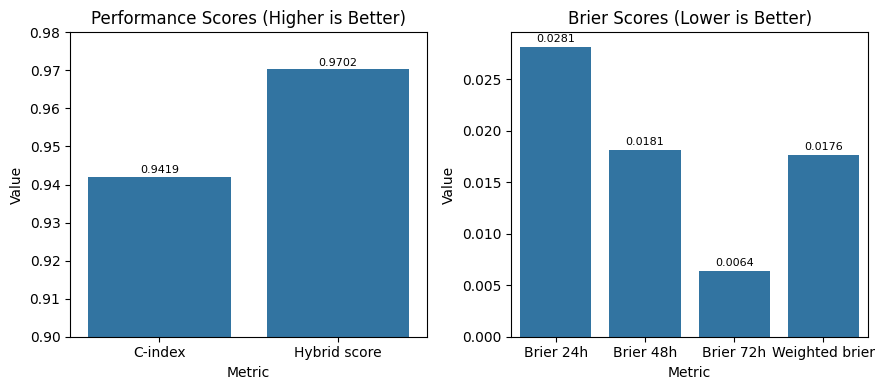

In [59]:
# p12 <= p24 <= p48 <= p72
oof_preds_gbsa = np.maximum.accumulate(oof_preds_gbsa, axis=1) # type: ignore
gbsa_test_preds = np.maximum.accumulate(gbsa_test_preds, axis=1) # type: ignore

# Calculating c_index
time_vals  = y_train['time_to_hit_hours'].values
event_vals = y_train['event'].values.astype(bool)
c_idx = concordance_index_censored(event_vals, time_vals, oof_preds_gbsa[:, 1])[0] # type: ignore

# Calculating brier score
oof_surv_prob = 1 - oof_preds_gbsa # type: ignore
max_time_stamp = max(y_train['time_to_hit_hours'])
horizons = np.array([24.0, 48.0, max_time_stamp - 0.000001])
surv_matrix = oof_surv_prob[:, 1:] # Remove 12h # type: ignore

_, brier_scores = brier_score(
    survival_train = y_train_surv,
    survival_test = y_train_surv,  
    estimate = surv_matrix,
    times = horizons
)

brier_score_24 = brier_scores[0] 
brier_score_48 = brier_scores[1]
brier_score_72 = brier_scores[2]

# Hybrid score (official evaluation)
w_brier = 0.3 * brier_score_24 + 0.4 * brier_score_48 + 0.3 * brier_score_72
hybrid  = 0.3 * c_idx + 0.7 * (1 - w_brier)
#----------------------------------------------------------------------
print(f"C-index        : {c_idx:.4f}")
print(f"Brier 24h      : {brier_score_24:.4f}")
print(f"Brier 48h      : {brier_score_48:.4f}")
print(f"Brier 72h      : {brier_score_72:.4f}")
print(f"Weighted brier : {w_brier:.4f}")
print(f"Hybrid Score   : {hybrid:.4f}") # Ranking sẽ dựa vào hybrid score

# Visualize the evaluation score
pred_values = {
    'Metric': ['C-index', 'Brier 24h', 'Brier 48h', 'Brier 72h', 'Weighted brier', 'Hybrid score'],
    'Value' : [c_idx, brier_score_24, brier_score_48, brier_score_72, w_brier, hybrid]
}
pred_values = pd.DataFrame(pred_values)

# Split into 2 groups
perf_df = pred_values[pred_values['Metric'].isin(['C-index', 'Hybrid score'])]
brier_df = pred_values[pred_values['Metric'].isin(['Brier 24h', 'Brier 48h', 'Brier 72h', 'Weighted brier'])]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Left: performance metrics
sns.barplot(data=perf_df, x='Metric', y='Value', ax=axes[0])
axes[0].set_title('Performance Scores (Higher is Better)')
axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Value')
axes[0].set_ylim(0.90, 0.98)

for i, v in enumerate(perf_df['Value']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)

# Right: Brier scores
sns.barplot(data=brier_df, x='Metric', y='Value', ax=axes[1])
axes[1].set_title('Brier Scores (Lower is Better)')
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Value')

for i, v in enumerate(brier_df['Value']):
    axes[1].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### LightGBM

In [60]:
# Initialize N_folds for lgbm
N_FOLDS_LGBM = 5

# Initialize random seeds for kFOLD
LGBM_SEEDS = [526, 484, 749, 852, 848]

# Initialize oof matrix prediction
oof_preds_lgbm = np.zeros((len(X_train), 4)) # 4 horizons: 12h, 24h, 48h, 72h

# Initialize final average test prediction
lgbm_test_preds = np.zeros((len(X_test), 4))

# Combine every y_train for each horizon
y_train_lgbm = pd.DataFrame({
    'p12': y_train_lgbm_p12,
    'p24': y_train_lgbm_p24,
    'p48': y_train_lgbm_p48,
    'p72': y_train_lgbm_p72
})
horizons = ['p12', 'p24', 'p48', 'p72']

# We need new X_train because of chain classifier
X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

##### Manual configs for each horizon

In [61]:
lgb_cfgs = {
    'p12': {"max_depth":2, "learning_rate":0.03, "n_estimators":500,
            "subsample":0.7, "colsample_bytree":0.7, "min_child_samples":10,
            "reg_alpha":1.0, "reg_lambda":3.0, "num_leaves":4},

    'p24': {"max_depth":3, "learning_rate":0.03, "n_estimators":500,
            "subsample":0.7, "colsample_bytree":0.7, "min_child_samples":8,
            "reg_alpha":0.5, "reg_lambda":2.0, "num_leaves":7},

    'p48': {"max_depth":2, "learning_rate":0.05, "n_estimators":500,
            "subsample":0.8, "colsample_bytree":0.8, "min_child_samples":5,
            "reg_alpha":0.1, "reg_lambda":1.0, "num_leaves":4},
            
    'p72': {"max_depth":2, "learning_rate":0.03, "n_estimators":500,
            "subsample":0.7, "colsample_bytree":0.7, "min_child_samples":10,
            "reg_alpha":1.0, "reg_lambda":3.0, "num_leaves":4},
}

##### Finding IPCW for lgbm

In [62]:
# IPCW weights for each horizon
# Removing bias from fire
ipcw_weights_per_horizon = {}
kmf = KaplanMeierFitter()
kmf.fit(
    durations  = y_train['time_to_hit_hours'],
    event_observed = (1 - y_train['event'])
)
horizon_hours = {'p12': 12, 'p24': 24, 'p48': 48, 'p72': 72}
for col, horizon in horizon_hours.items():
    y_horizon = y_train_lgbm[col].values
    weights = np.zeros(len(y_train))

    for idx in range(len(y_train)):
        train_hour = y_train['time_to_hit_hours'].iloc[idx]
        event_value = y_train['event'].iloc[idx]

        if event_value == 1 and train_hour <= horizon:
            # Uncensored event before horizon → upweight by 1/G(t_i)
            g_t = kmf.survival_function_at_times(train_hour).values[0]
            weights[idx] = 1.0 / max(g_t, 1e-6)
        else:
            weights[idx] = 1.0

    ipcw_weights_per_horizon[col] = weights
    print(f"{col} (horizon={horizon}h) | events: {y_horizon.sum()} "
          f"| weight range: [{weights.min():.3f}, {weights.max():.3f}] "
          f"| mean weight on events: {weights[y_horizon==1].mean():.3f}")   

p12 (horizon=12h) | events: 49 | weight range: [1.000, 1.032] | mean weight on events: 1.014
p24 (horizon=24h) | events: 63 | weight range: [1.000, 1.172] | mean weight on events: 1.033
p48 (horizon=48h) | events: 66 | weight range: [1.000, 1.473] | mean weight on events: 1.050
p72 (horizon=72h) | events: 69 | weight range: [1.000, 49.518] | mean weight on events: 1.768


##### LightGBM OOF loop

In [63]:
for i, horizon in enumerate(horizons):
    horizon_oof = np.zeros(len(X_train))
    horizon_test = np.zeros(len(X_test))    
    for seed in LGBM_SEEDS:
        # Initialize K-Fold
        skf = StratifiedKFold(
            n_splits=N_FOLDS_LGBM,
            shuffle=True,
            random_state=seed
        )
        # Prediction for each seed
        seed_oof = np.zeros(len(X_train))
        seed_test_preds = np.zeros(len(X_test))
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_lgbm, y_train_lgbm[horizon])):
            # Indentify train and validation row
            X_tr, X_val = X_train_lgbm.iloc[train_idx].copy(), X_train_lgbm.iloc[val_idx].copy()
            y_tr = y_train_lgbm[horizon].values[train_idx]
            X_test_fold = X_test_lgbm.copy()
            y_val = y_train_lgbm[horizon].values[val_idx]

            # Target encoding for categorical data
            target_encoder = TargetEncoder(cols=category_col, smoothing=10)
            X_tr[category_col] = target_encoder.fit_transform(X_tr[category_col], y_tr)
            X_val[category_col] = target_encoder.transform(X_val[category_col])
            X_test_fold[category_col] = target_encoder.transform(X_test_fold[category_col])

            # Initialize lightgbm
            lgbm = LGBMClassifier(
                **{**lgb_cfgs[horizon],
                "objective": "binary",
                "metric": "binary_logloss",
                "verbose": -1,
                "random_state": seed}
            )
            lgbm.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],         
                callbacks=[
                    early_stopping(stopping_rounds=50, verbose=False),
                    log_evaluation(period=-1) # keep this shut up              
                ],
                sample_weight=ipcw_weights_per_horizon[horizon][train_idx]
            )

            # Train data 
            # shape = (number_of_samples, number_of_classes)
            seed_oof[val_idx] += lgbm.predict_proba(X_val)[:, 1] # type: ignore

            # Fit X_test (Dividing N_FOLDS for every fold in 5 total folds)
            seed_test_preds += lgbm.predict_proba(X_test_fold)[:, 1] / N_FOLDS_LGBM# type: ignore

        horizon_oof += seed_oof / len(LGBM_SEEDS) # Shape (X_train, 1)
        horizon_test += seed_test_preds / len(LGBM_SEEDS) # Shape (X_train, 1)
    
    oof_preds_lgbm[:, i] = horizon_oof
    lgbm_test_preds[:, i] = horizon_test
        
    # Chain classifier 
    # Add previous predict horizon to new X_train to train the next time stamp
    if i < len(horizons) - 1:
        X_train_lgbm[f'oof_{horizon}'] = horizon_oof
        X_test_lgbm[f'oof_{horizon}'] = horizon_test      

### LightGBM evaluation (ROC AUC)

In [64]:
# p12 <= p24 <= p48 <= p72
oof_preds_lgbm = np.maximum.accumulate(oof_preds_lgbm, axis=1) # type: ignore
lgbm_test_preds = np.maximum.accumulate(lgbm_test_preds, axis=1) # type: ignore

overall_score = roc_auc_score(y_train_lgbm, oof_preds_lgbm, average='macro')
print(f"Average ROC-AUC Score: {overall_score:.4f}")

Average ROC-AUC Score: 0.9885


### PLatt Scaling W Logistic Regression For LGBM

In [65]:
y_train_lgbm.head(3)

,p12,p24,p48,p72
0,0,0,0,0
1,0,1,1,1
2,1,1,1,1


##### Calibrated lgbm

In [66]:
# Calibrated for each horizon
# horizons = ['p12', 'p24', 'p48', 'p72']
lgbm_oof_cal = np.zeros_like(oof_preds_lgbm)
lgbm_test_cal = np.zeros_like(lgbm_test_preds)

for i, horizon in enumerate(horizons):
    y_true = y_train_lgbm[horizon].values
    oof_col = oof_preds_lgbm[:, i].reshape(-1, 1)
    test_col = lgbm_test_preds[:, i].reshape(-1, 1)

    log_res = LogisticRegression()
    log_res.fit(oof_col, y_true) # type: ignore

    lgbm_oof_cal[:, i] = log_res.predict_proba(oof_col)[:, 1]
    lgbm_test_cal[:, i] = log_res.predict_proba(test_col)[:, 1]

lgbm_oof_cal = np.maximum.accumulate(lgbm_oof_cal, axis=1)
lgbm_test_cal = np.maximum.accumulate(lgbm_test_cal, axis=1)

### Fixed Blend Horizon (GBSA + LGBM)

In [67]:
def compute_c_hybrid(oof_matrix):
    # Calculating c_index
    c_idx = concordance_index_censored(event_vals, time_vals, oof_matrix[:, 1])[0] # type: ignore

    # Calculating brier score
    oof_surv_prob = 1 - oof_matrix # type: ignore
    max_time_stamp = max(y_train['time_to_hit_hours'])
    horizons = np.array([24.0, 48.0, max_time_stamp - 0.000001])
    surv_matrix = oof_surv_prob[:, 1:] # Remove 12h # type: ignore
    # Function never gets queried beyond the last observed time
    clamped_horizons = np.clip(horizons, None, max_time_stamp - 0.000001)

    _, brier_scores = brier_score(
        survival_train = y_train_surv,
        survival_test = y_train_surv,  
        estimate = surv_matrix,
        times = clamped_horizons
    )

    brier_score_24 = brier_scores[0] 
    brier_score_48 = brier_scores[1]
    brier_score_72 = brier_scores[2]

    # Hybrid score (official evaluation)
    w_brier = 0.3 * brier_score_24 + 0.4 * brier_score_48 + 0.3 * brier_score_72
    hybrid  = 0.3 * c_idx + 0.7 * (1 - w_brier)
    return hybrid

##### Use blend weight to blend gbsa and lgbm 

In [68]:
W_GBSA_12, W_LGB_12 = 0.97, 0.03   # LGB barely helps at 12h
W_GBSA_24, W_LGB_24 = 0.95, 0.05   # GBSA dominant
W_GBSA_48, W_LGB_48 = 0.45, 0.55   # LGB actually wins at 48h

In [69]:
blended_oof = np.zeros((len(oof_preds_lgbm), 4))

blended_oof[:, 0] = oof_preds_gbsa[:, 0] * W_GBSA_12 + lgbm_oof_cal[:, 0] * W_LGB_12
blended_oof[:, 1] = oof_preds_gbsa[:, 1] * W_GBSA_24 + lgbm_oof_cal[:, 1] * W_LGB_24
blended_oof[:, 2] = oof_preds_gbsa[:, 2] * W_GBSA_48 + lgbm_oof_cal[:, 2] * W_LGB_48
blended_oof[:, 3] = oof_preds_gbsa[:, 3]

blended_oof = np.maximum.accumulate(blended_oof, axis=1) # type: ignore
blended_oof_copy = blended_oof.copy()
blended_oof_copy = pd.DataFrame(blended_oof_copy)
blended_oof_copy.head(3)

,0,1,2,3
0,0.018005,0.045212,0.060903,0.115958
1,0.804089,0.973594,0.973594,0.999995
2,0.993247,0.994073,0.994073,1.000000


In [70]:
final_preds =  np.zeros((len(gbsa_test_preds), 4))

final_preds[:, 0] = gbsa_test_preds[:, 0] * W_GBSA_12 + lgbm_test_cal[:, 0] * W_LGB_12
final_preds[:, 1] = gbsa_test_preds[:, 1] * W_GBSA_24 + lgbm_test_cal[:, 1] * W_LGB_24
final_preds[:, 2] = gbsa_test_preds[:, 2] * W_GBSA_48 + lgbm_test_cal[:, 2] * W_LGB_48
final_preds[:, 3] = gbsa_test_preds[:, 3]

final_preds = np.maximum.accumulate(final_preds, axis=1) # type: ignore
final_preds_copy = final_preds.copy()
final_preds_copy = pd.DataFrame(final_preds_copy)
final_preds_copy.head(3)

,0,1,2,3
0,0.016765,0.042076,0.057895,0.117220
1,0.625128,0.919813,0.930597,0.997572
2,0.015633,0.039169,0.055820,0.108834


### Final evaluation

In [71]:
# Free gain
blended_oof[:, 3] = 1.0
final_preds[:, 3] = 1.0

blended_oof = np.maximum.accumulate(blended_oof, axis=1)
final_preds = np.maximum.accumulate(final_preds, axis=1)

print(f"Hybrid score: {compute_c_hybrid(blended_oof):.4f}")

Hybrid score: 0.8769


### Final submissions 

##### Temporary: Submission test for lgbm

In [72]:
submission = {
    'event_id' : event_id,
    'prob_12h' : lgbm_test_preds[:, 0], # type: ignore
    'prob_24h' : lgbm_test_preds[:, 1], # type: ignore
    'prob_48h' : lgbm_test_preds[:, 2], # type: ignore
    'prob_72h' : lgbm_test_preds[:, 3]  # type: ignore
}
submission = pd.DataFrame(submission)
submission.to_csv('lgbm_preds.csv', index=False)

##### Temporary: Submission test for gbsa

In [73]:
submission = {
    'event_id' : event_id,
    'prob_12h' : gbsa_test_preds[:, 0],# type: ignore
    'prob_24h' : gbsa_test_preds[:, 1],# type: ignore
    'prob_48h' : gbsa_test_preds[:, 2],# type: ignore
    'prob_72h' : gbsa_test_preds[:, 3] # type: ignore
}
submission = pd.DataFrame(submission)
submission.to_csv('gbsa_preds.csv', index=False)

##### Kaggle submission

In [75]:
submission = {
    'event_id' : event_id,
    'prob_12h' : final_preds[:, 0],# type: ignore
    'prob_24h' : final_preds[:, 1],# type: ignore
    'prob_48h' : final_preds[:, 2],# type: ignore
    'prob_72h' : final_preds[:, 3] # type: ignore
}
submission = pd.DataFrame(submission)
submission.to_csv('final_preds.csv', index=False)